In [32]:
import lightning as L
import matplotlib.pyplot as plt
import mrcfile
import torch
from torch.utils.data import DataLoader, TensorDataset

from cryosim.array_utils import ball3d, compute_nps_2d
from cryosim.cryosparc_utils import extract_parameters_from_csfile
from cryosim.ghostbuster import Ghostbuster
from cryosim.plotting_tools import plot3d, plot_particle_stack, VolumeMonitorCallback
from cryosim.fft_tools import halfmap_fsc_weight_2d
from cryosim.fft_tools import fourier_shell_correlation as fsc


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# params
device = 1
return_class = "1"
scattering_model = "rytov"
randomize_phases = False
sparsity = 0
lr = 0.1
symmetry = "I1"  #'I1'
niter = 5
dose_per_angstrom = 22.5

## Import GT

In [3]:
path = "/scratch/loh/joel/empiar-10202/aav2_0788.mrc"
with mrcfile.open(path) as mrc:
    gt = torch.as_tensor((mrc.data).copy())
gt.shape

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


torch.Size([512, 512, 512])

In [4]:
avgpool = torch.nn.AvgPool3d(2, stride=2)
gt_bin2 = torch.squeeze(avgpool(gt[None, None, ...]))
gt_bin4 = torch.squeeze(avgpool(gt_bin2[None, None, ...]))
gt_bin8 = torch.squeeze(avgpool(gt_bin4[None, None, ...]))

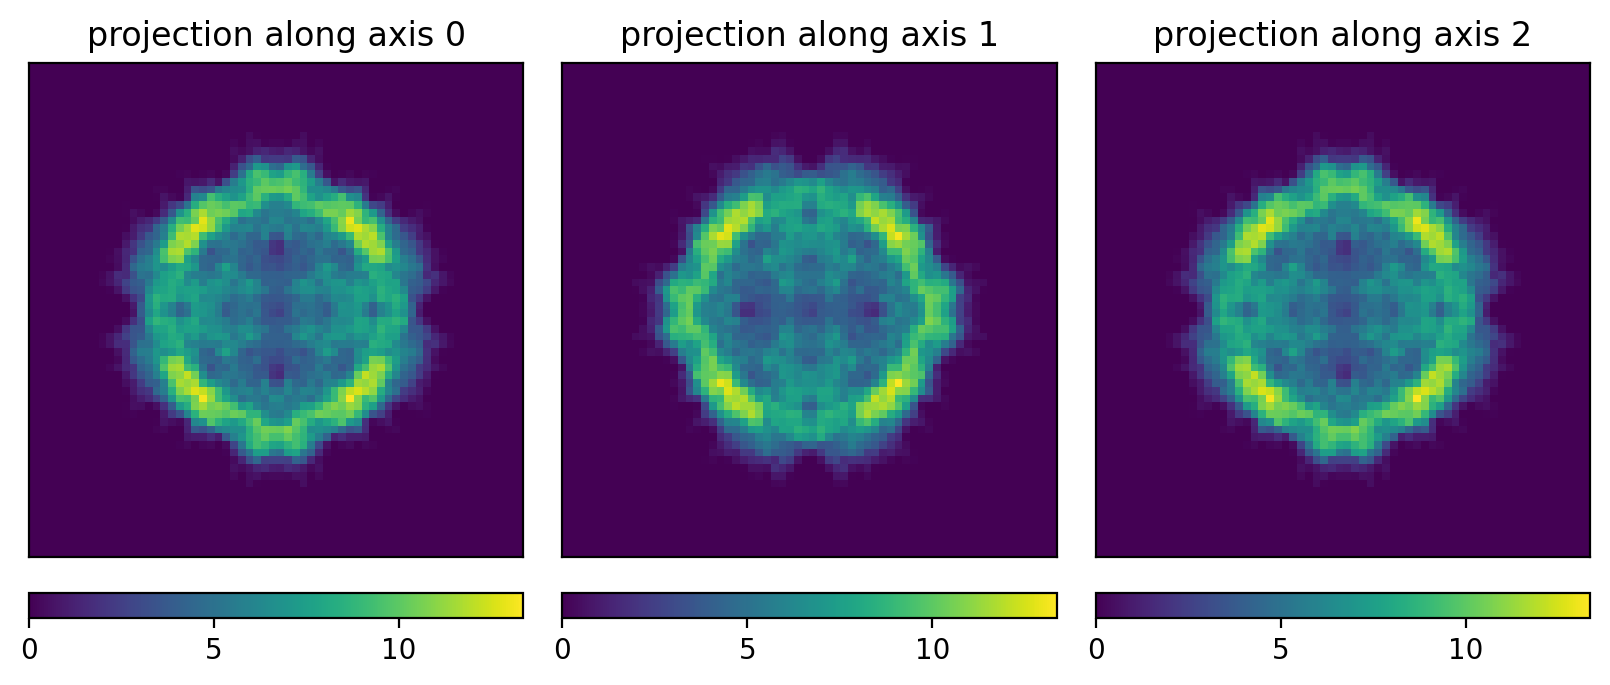

In [5]:
plot3d(gt_bin8)

## Import cryoSPARC

In [6]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_map_half_A.mrc"  # all particles
with mrcfile.open(path) as mrc:
    cryosparc = torch.as_tensor((mrc.data).copy())
cryosparc.shape

torch.Size([512, 512, 512])

In [7]:
cryosparc_bin2 = torch.squeeze(avgpool(cryosparc[None, None, ...]))
cryosparc_bin4 = torch.squeeze(avgpool(cryosparc_bin2[None, None, ...]))
cryosparc_bin8 = torch.squeeze(avgpool(cryosparc_bin4[None, None, ...]))

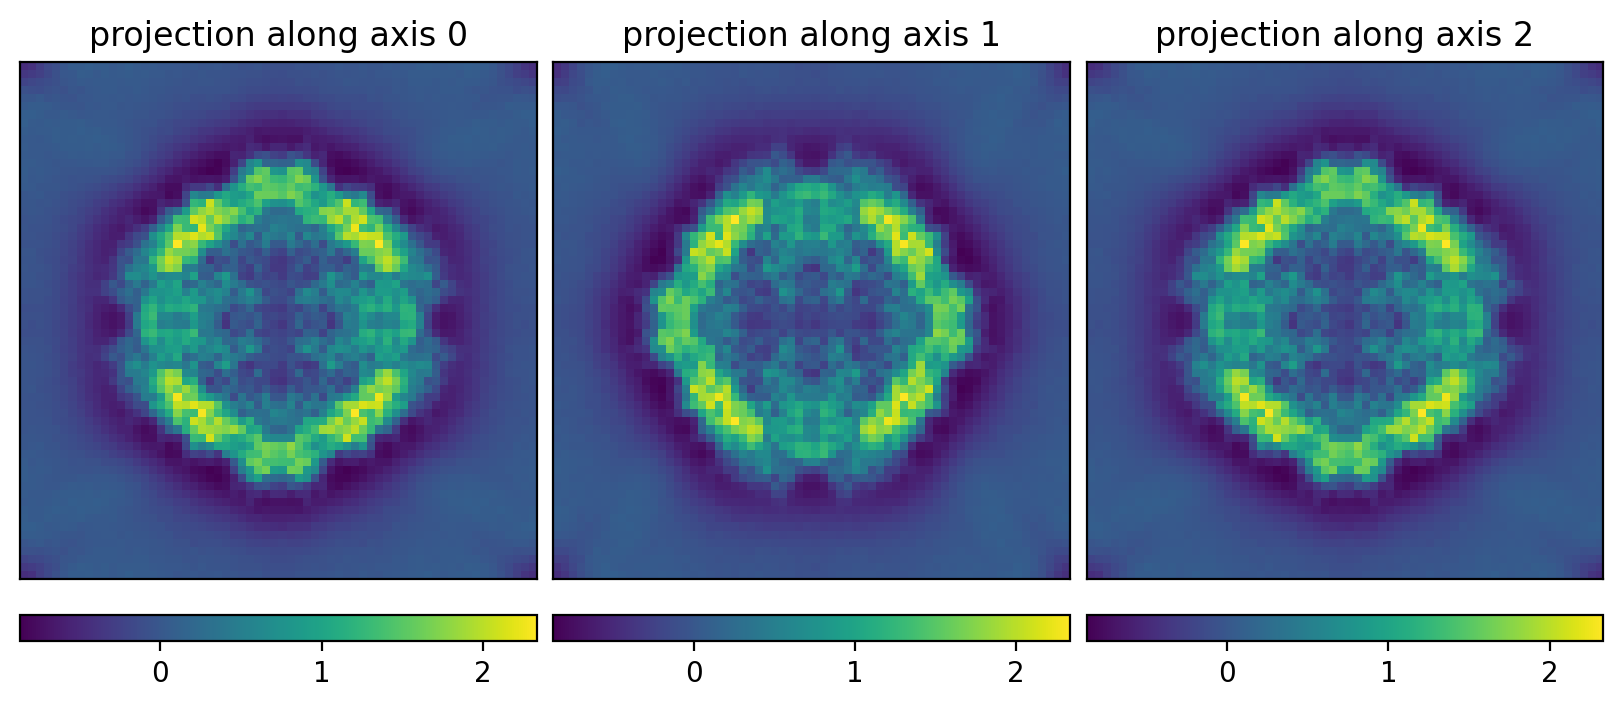

In [8]:
plot3d(cryosparc_bin8)

In [9]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_mask_fsc.mrc"  # all particles
with mrcfile.open(path) as mrc:
    mask = torch.as_tensor((mrc.data).copy())
mask.shape

torch.Size([512, 512, 512])

In [10]:
mask_bin2 = torch.squeeze(avgpool(mask[None, None, ...]))
mask_bin4 = torch.squeeze(avgpool(mask_bin2[None, None, ...]))
mask_bin8 = torch.squeeze(avgpool(mask_bin4[None, None, ...]))

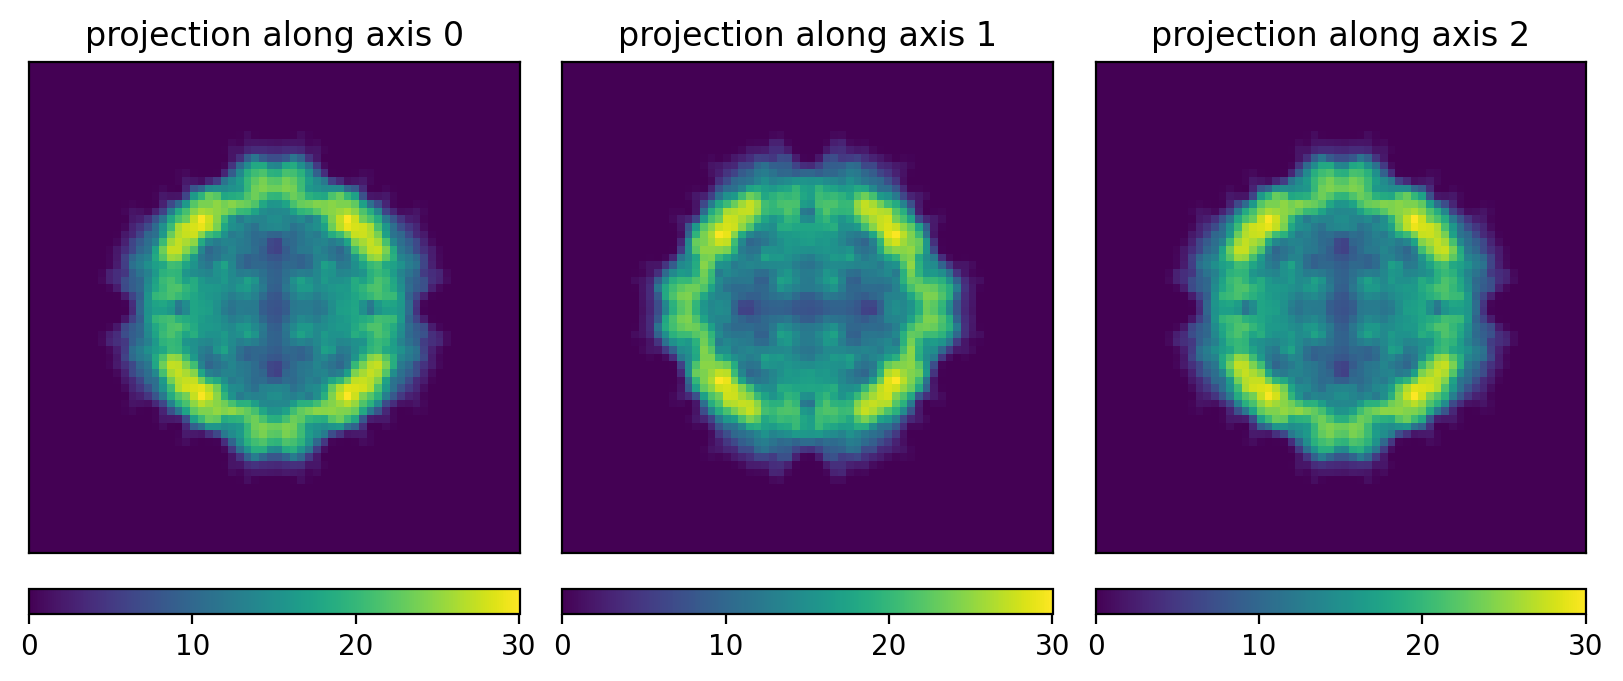

In [11]:
plot3d(mask_bin8)

## Import data

In [12]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_particles.cs"  # all particles
(
    energy,
    orig_pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
) = extract_parameters_from_csfile(path, return_class=return_class)

rotations.shape, translations_A.shape, anisomag.shape

(torch.Size([15257, 4]), torch.Size([15257, 2]), torch.Size([15257, 2, 2]))

In [13]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J247/restack/batch_0_restacked.mrc"  # all particles
with mrcfile.open(path) as mrc:
    images_flip = torch.as_tensor((mrc.data[indices]).copy())
images_flip.shape

torch.Size([15257, 512, 512])

In [14]:
# sign flip data
n = images_flip.shape[-1]
images = -images_flip

## Compute Noise Power Spectrum as MSELoss weight

In [15]:
# rescale images
dose_per_area = dose_per_angstrom * (orig_pixel_size) ** 2
images = dose_per_area**0.5 * scale[..., None, None] * images + dose_per_area

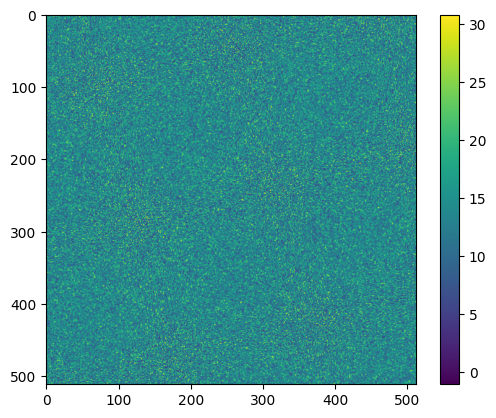

In [16]:
plt.imshow(images[0])
plt.colorbar()

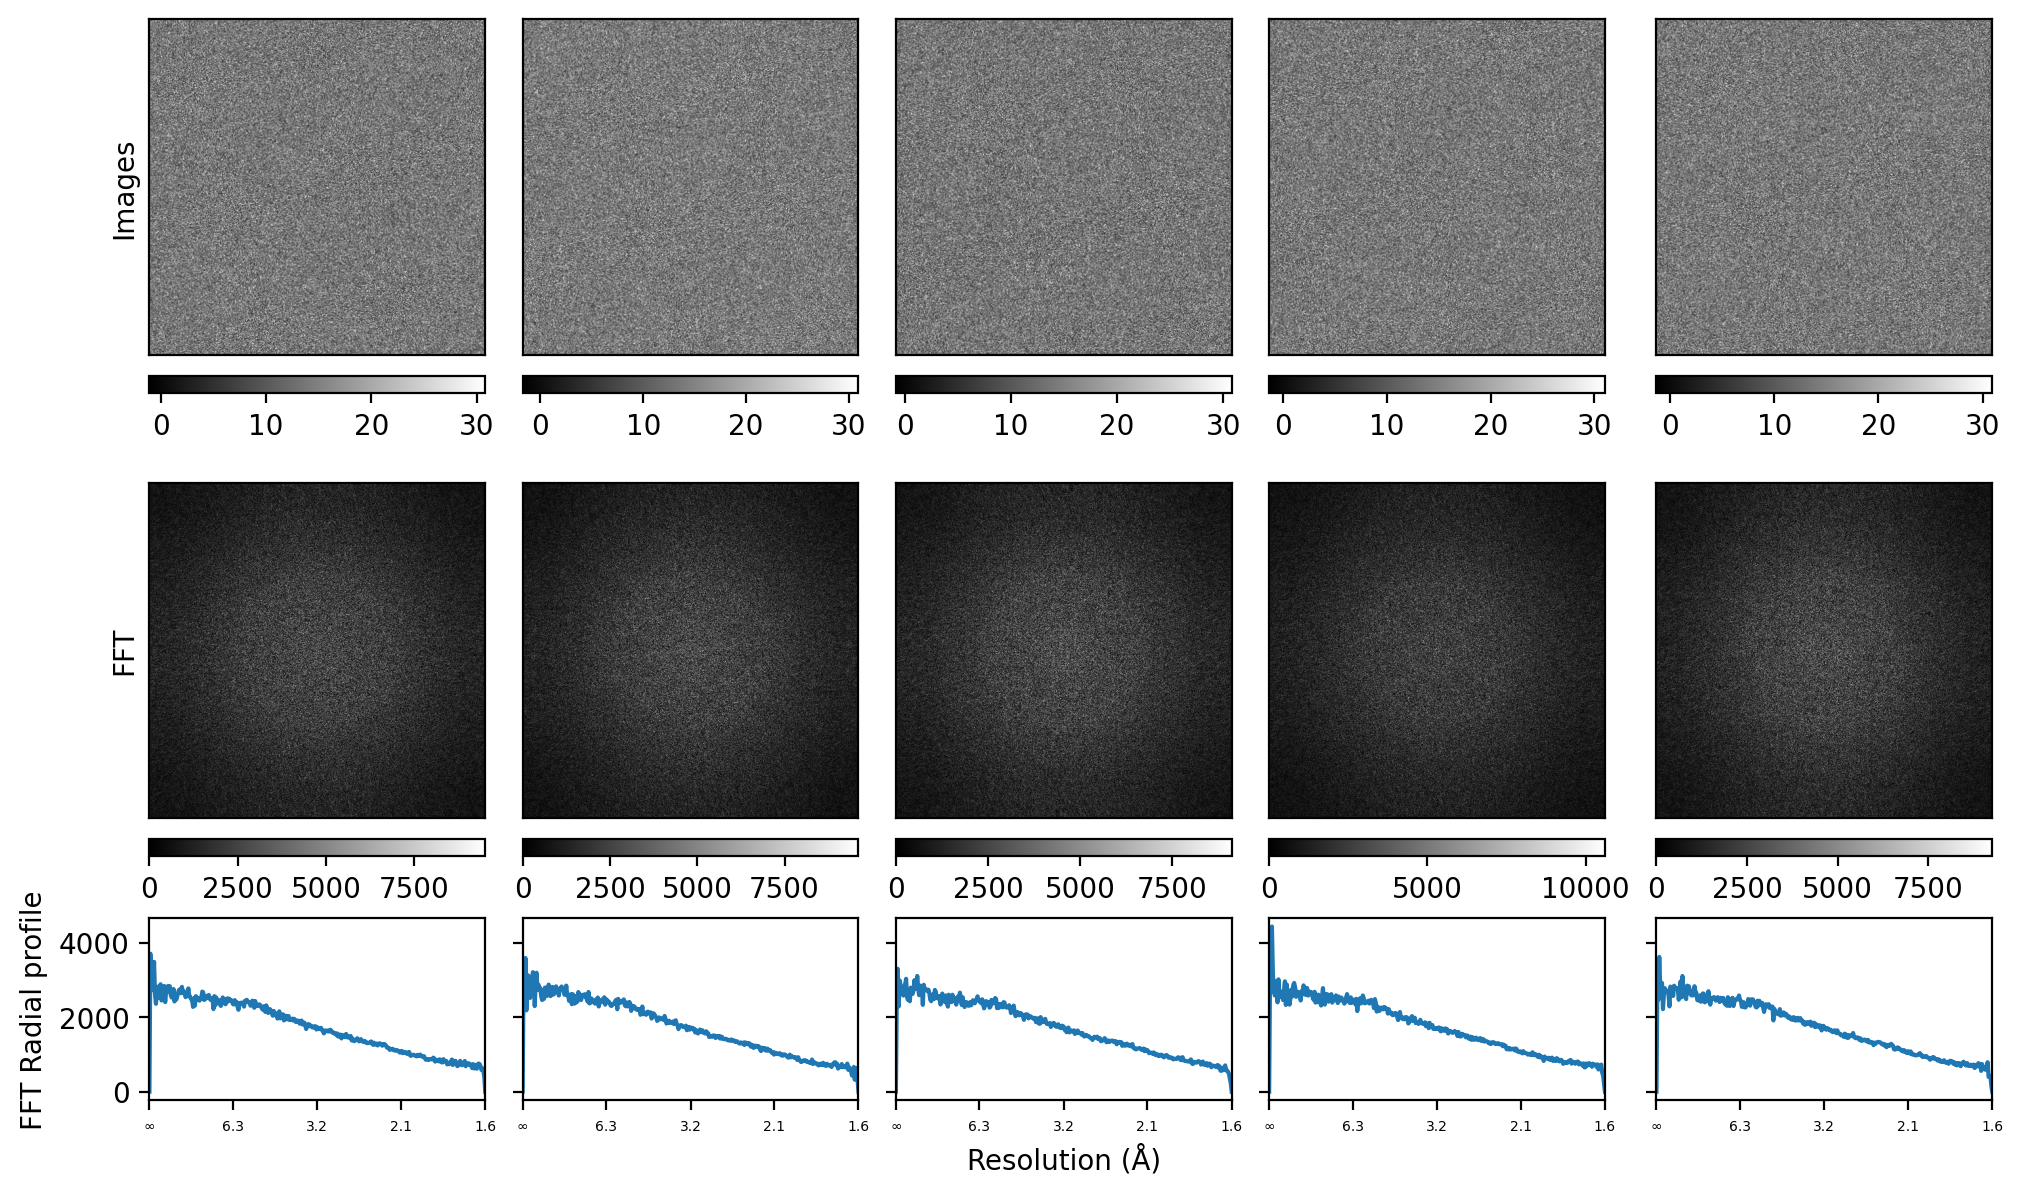

In [17]:
plot_particle_stack(images, orig_pixel_size)

In [55]:
nps_weight = compute_nps_2d(images)

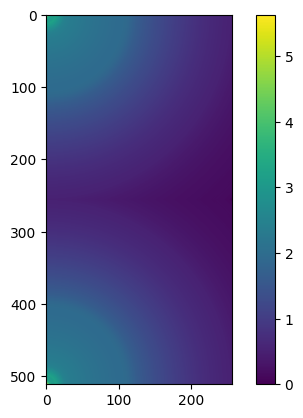

In [56]:
plt.imshow(nps_weight)
plt.colorbar()

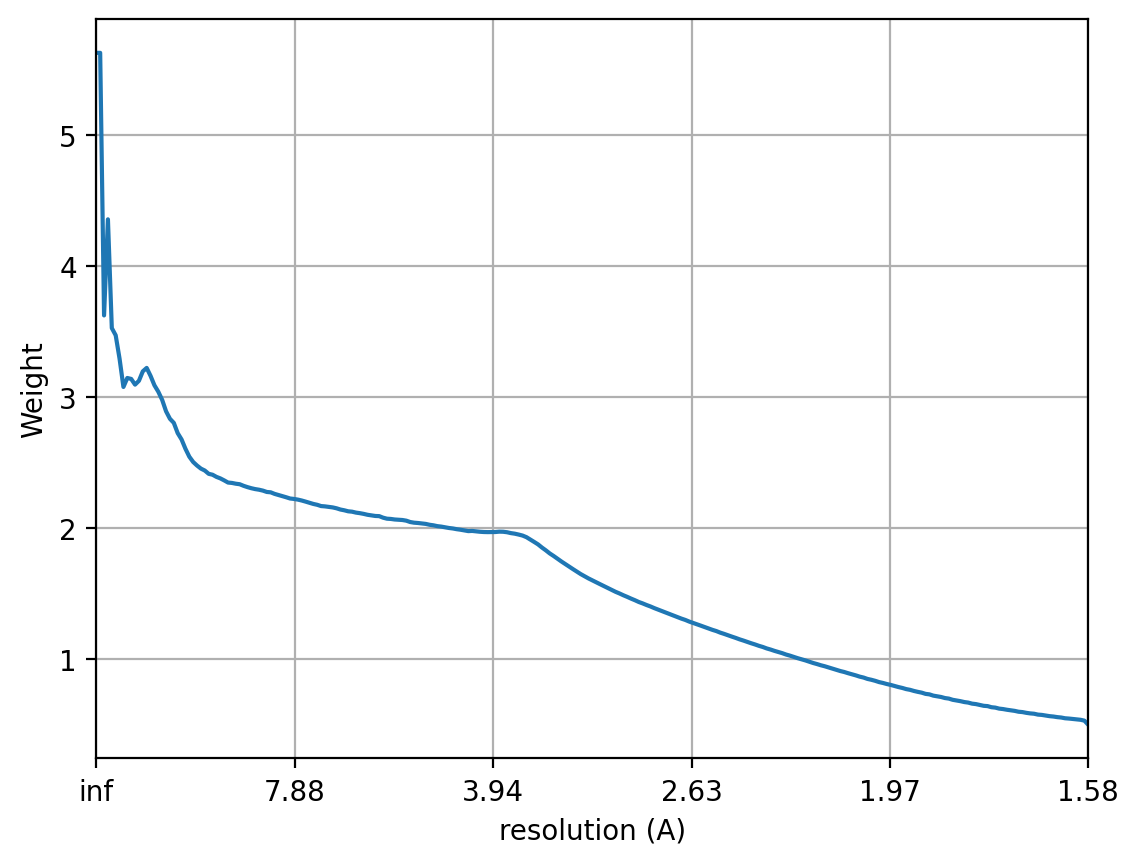

In [57]:
# fig, axes = plt.subplots(1, 1, dpi=200)
# xticks = torch.linspace(0, 1/orig_pixel_size/2, 6)
# axes.set(
#     xticks=xticks,
#     xticklabels=[f"{1/x:.2f}" for x in xticks],
#     xlabel="resolution (A)",
#     ylabel="Weight",
#     # ylim=[-0.05, 1.05],
#     xlim=[0, 1/orig_pixel_size/2],
# )
# axes.plot(r1[:257], nps_weight.cpu()[0])
# axes.grid()

## Use FSC weights instead

In [34]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_map_half_A.mrc"  # all particles
with mrcfile.open(path) as mrc:
    cs_A = torch.as_tensor((mrc.data).copy())
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_map_half_B.mrc"  # all particles
with mrcfile.open(path) as mrc:
    cs_B = torch.as_tensor((mrc.data).copy())

In [35]:
nps_weight = halfmap_fsc_weight_2d(cs_A * mask, cs_B * mask, pixelsize=orig_pixel_size)

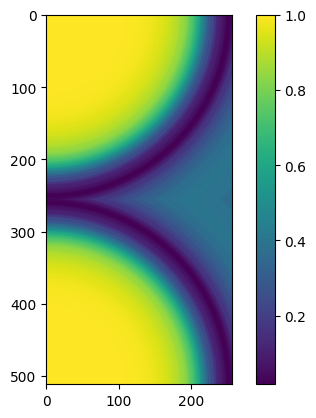

In [36]:
plt.imshow(nps_weight)
plt.colorbar()

## 3D reconstruction

In [37]:
klim = None  # or None
positivity = False

params = {
    "lr": lr,
    "symmetry": symmetry,
    "sparsity": sparsity,
    "rotate_mode": "real",
    "flipcurvature": True,
    "symmetry_batchsize": 3,
}

In [38]:
# upsample volume
volume_init = torch.zeros(images.shape[-1], images.shape[-1], images.shape[-1])
# num_particles = 100
num_particles = len(images)

idx = torch.arange(num_particles)
training_dataset = TensorDataset(images[:num_particles], idx)
train_loader1 = DataLoader(training_dataset, batch_size=3, num_workers=31)

In [39]:
kmask = ball3d(images.shape[-1], images.shape[-1])

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Single parameter optimization mode.


Create first Born propagators:   0%|          | 0/512 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/mnt/cbis/home/e0788253/czii/cryosim/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | imagegenerator | ImageGenerator | 0      | train
  | other params   | n/a            | 134 M  | n/a  
----------------------------------------------------------
134 M     Trainable params
0         Non-trainable params
134 M     Total params
536.871   Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Training: |                                               | 0/? [00:00<?, ?it/s]

/mnt/cbis/home/e0788253/czii/cryosim/.venv/lib/python3.11/site-packages/lightning/pytorch/core/module.py:520: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


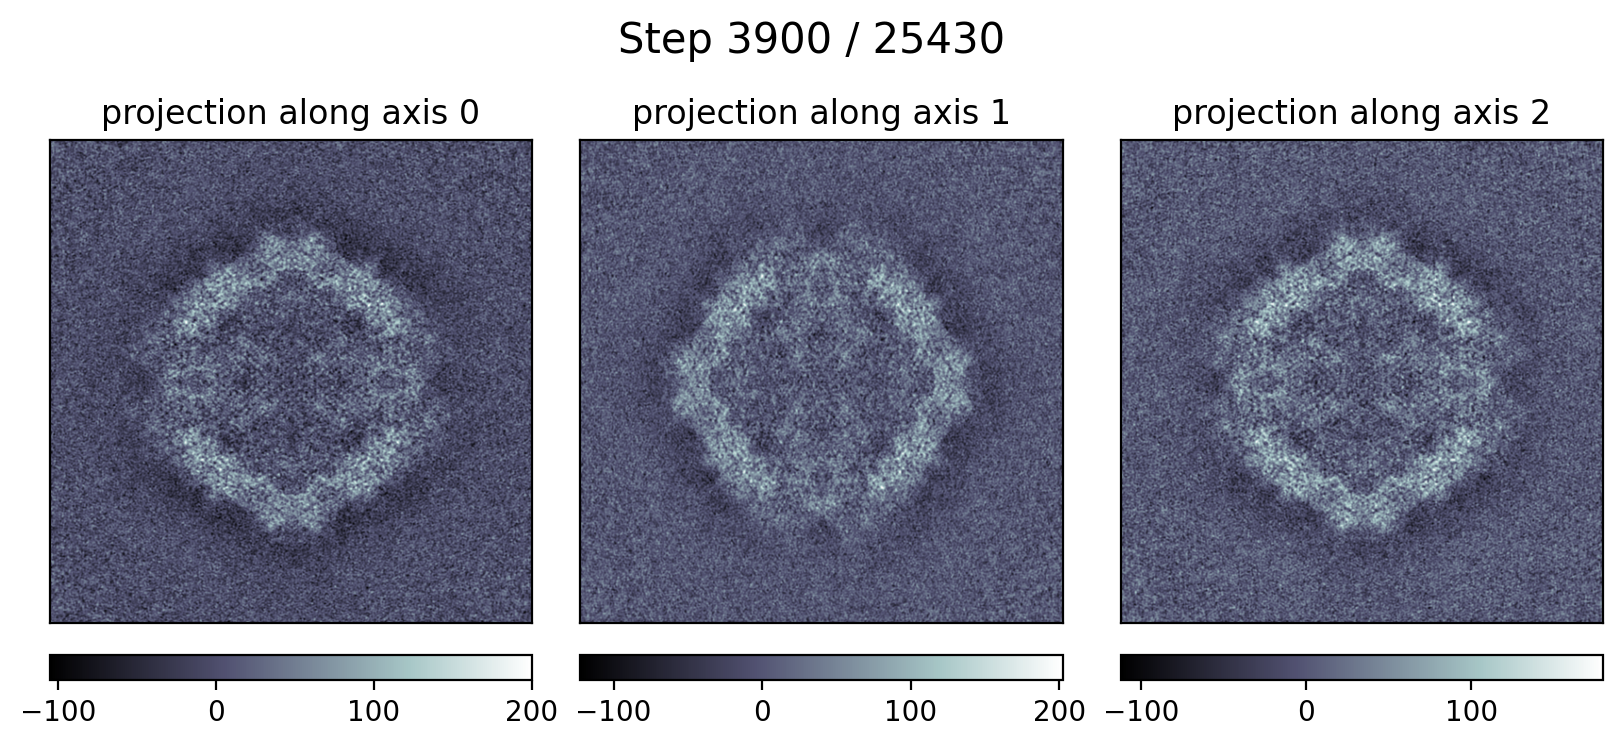

In [ ]:
trainer = L.Trainer(
    accelerator="gpu",
    devices=[device],
    max_epochs=niter,
    precision="16-mixed",
    logger=False,
    enable_checkpointing=False,
    callbacks=[VolumeMonitorCallback(every_n_steps=100)],
)
model1 = Ghostbuster(
    volume_init,
    orig_pixel_size,
    rotations,
    translations_A,
    ctf_params,
    energy,
    dose_per_angstrom,
    anisomag=anisomag,
    alpha=alpha,
    scattering_model=scattering_model,
    nps_weight=nps_weight,
    # defocus_offset=torch.tensor(30.),
    fsc_ref=gt,
    fsc_mask=mask,
    kmask=kmask,
    **params,
)
# tuner = Tuner(trainer)
# lr_finder1 = tuner.lr_find(model1, train_loader1, min_lr=1e-5, max_lr=1e1)
trainer.fit(model1, train_loader1)

In [ ]:
V_bin1 = model1.V.detach()
V_bin1.shape

In [ ]:
plot3d(V_bin1, cmap="bone")

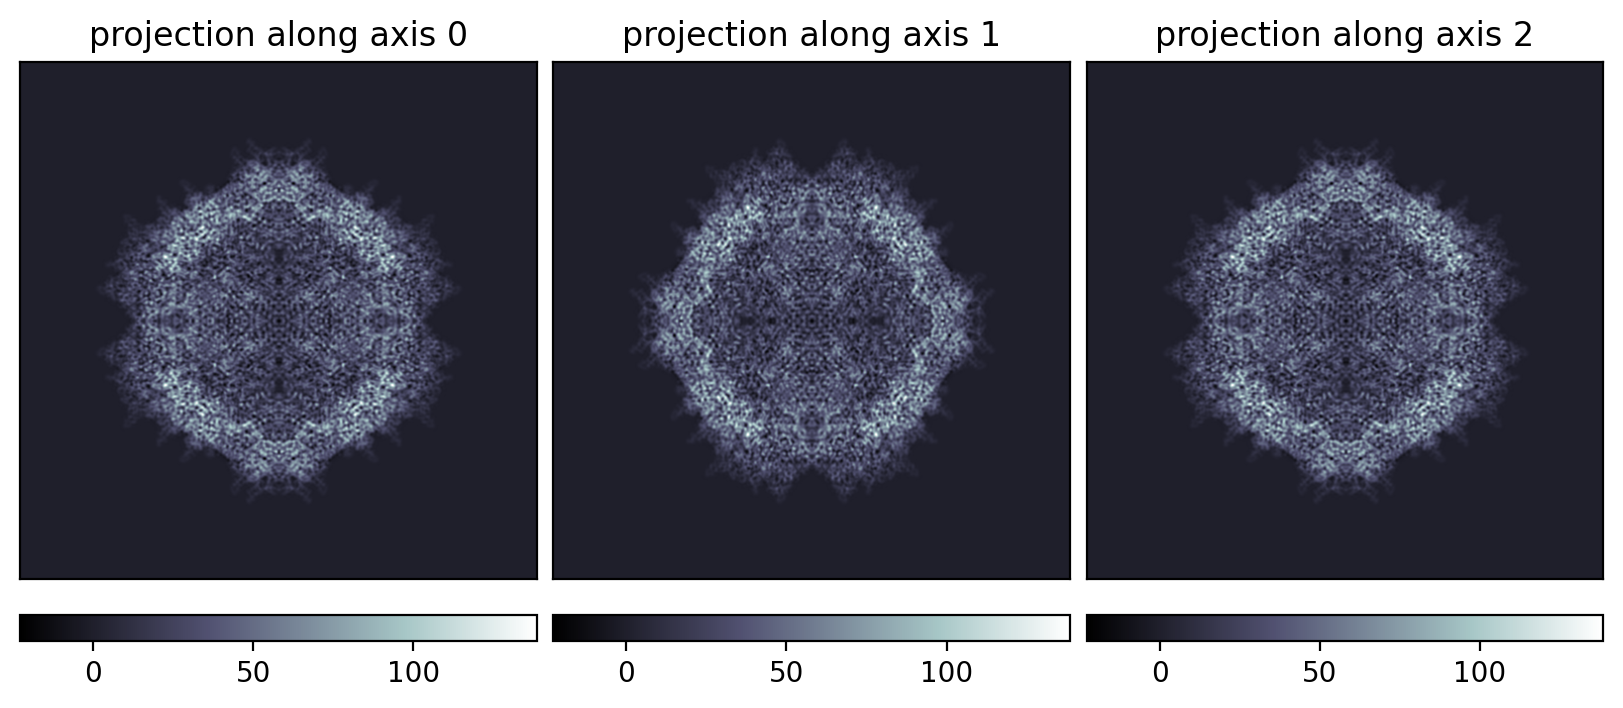

In [49]:
plot3d(V_bin1 * mask, cmap="bone")

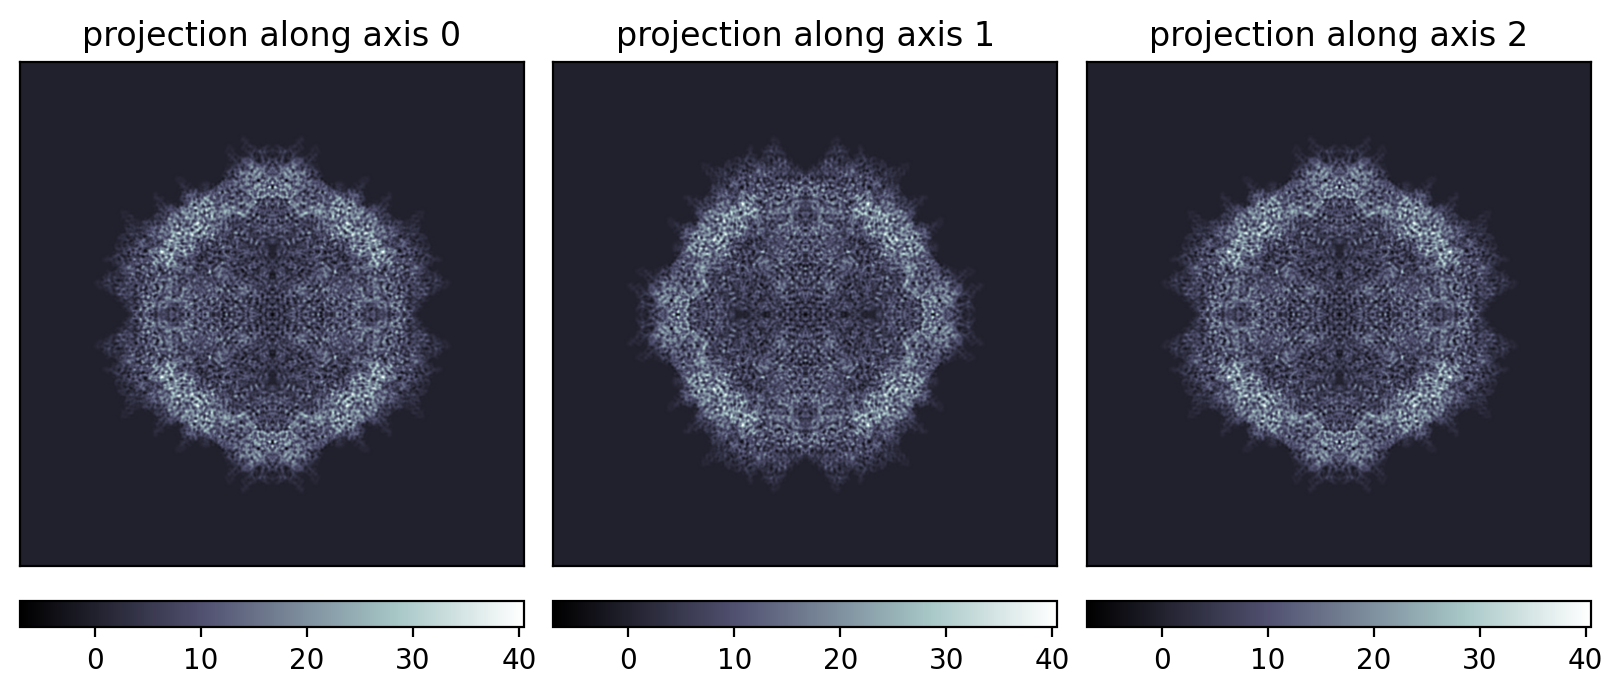

In [50]:
plot3d(cryosparc * mask, cmap="bone")

In [ ]:
r1, g1_fsc = fsc(V_bin1 * mask, gt, pixelsize=orig_pixel_size)

In [ ]:
r1, cs1_fsc = fsc(cryosparc * mask, gt, pixelsize=orig_pixel_size)

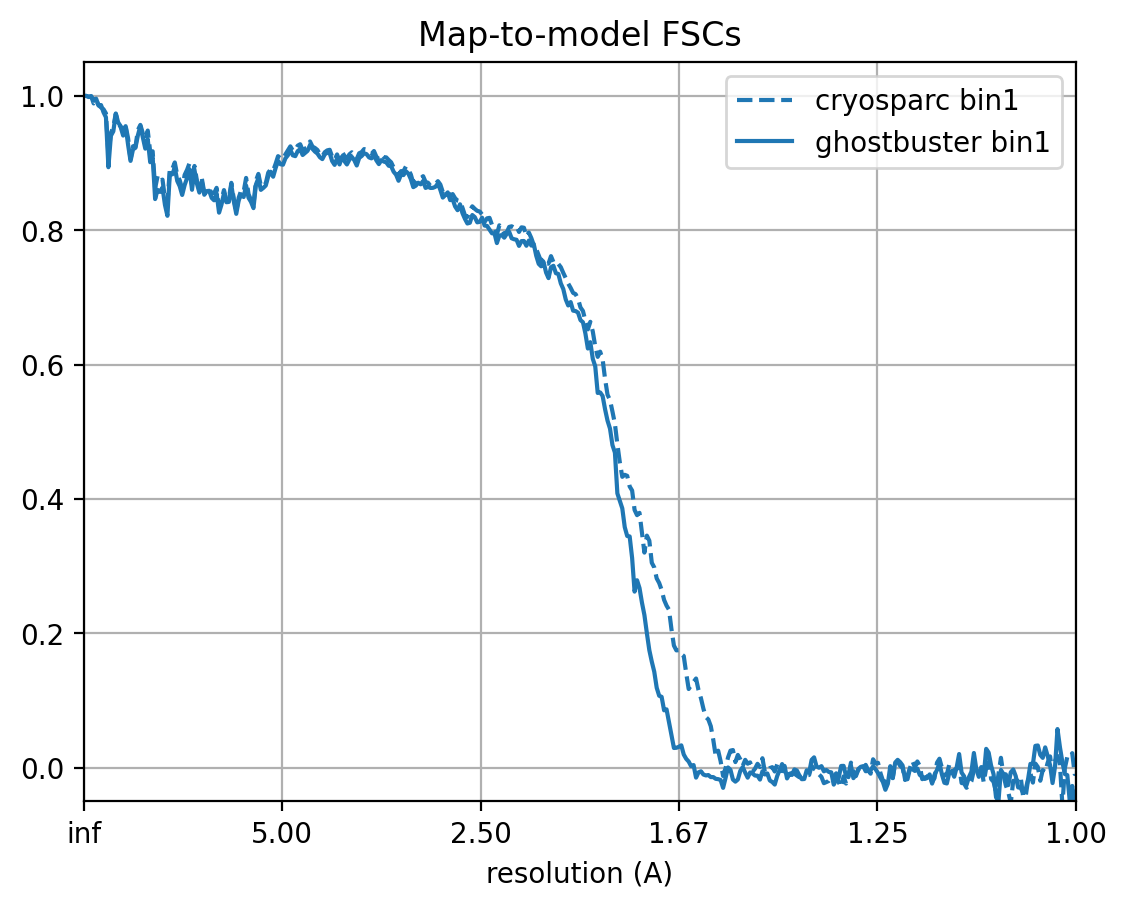

In [48]:
fig, axes = plt.subplots(1, 1, dpi=200)
xticks = torch.linspace(0, 1, 6)
axes.set(
    xticks=xticks,
    xticklabels=[f"{1/x:.2f}" for x in xticks],
    xlabel="resolution (A)",
    title="Map-to-model FSCs",
    ylim=[-0.05, 1.05],
    xlim=[0, 1],
)
axes.plot(r1, cs1_fsc, label="cryosparc bin1", color="C0", ls="--")
axes.plot(r1, g1_fsc, label="ghostbuster bin1", color="C0")
plt.legend()
plt.grid()
plt.show()

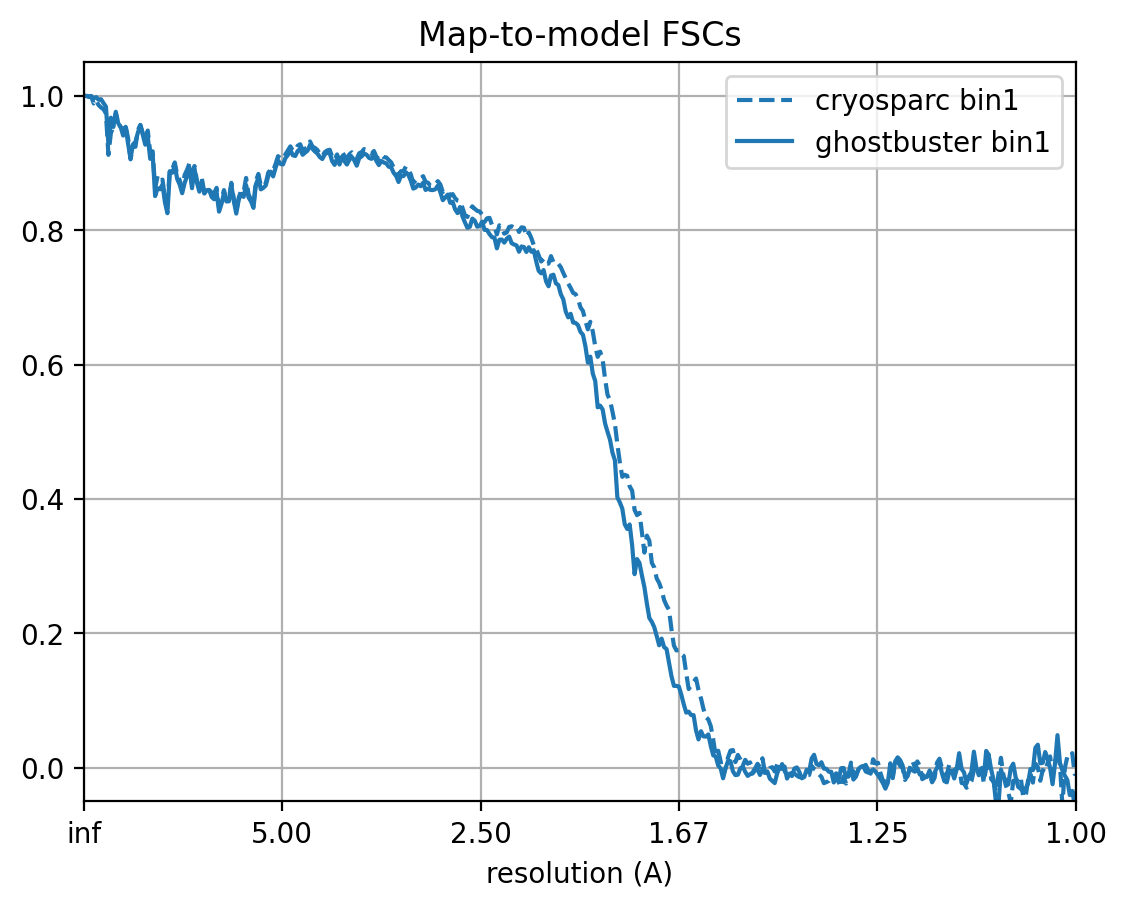

In [31]:
fig, axes = plt.subplots(1, 1, dpi=200)
xticks = torch.linspace(0, 1, 6)
axes.set(
    xticks=xticks,
    xticklabels=[f"{1/x:.2f}" for x in xticks],
    xlabel="resolution (A)",
    title="Map-to-model FSCs",
    ylim=[-0.05, 1.05],
    xlim=[0, 1],
)
axes.plot(r1, cs1_fsc, label="cryosparc bin1", color="C0", ls="--")
axes.plot(r1, g1_fsc, label="ghostbuster bin1", color="C0")
plt.legend()
plt.grid()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, dpi=200)
xticks = torch.linspace(0, 1 / orig_pixel_size / 2, 6)
axes.set(
    xticks=xticks,
    xticklabels=[f"{1/x:.2f}" for x in xticks],
    xlabel="resolution (A)",
    ylabel="Weight",
    # ylim=[-0.05, 1.05],
    xlim=[0, 1 / orig_pixel_size / 2],
)
axes.plot(r1[:257], nps_weight.cpu()[0])
axes.grid()